# Future Directions in ABM Calibration

Calibration of stochastic agent-based models can require many thousands of simulations.

This raises an important question:

> **Can we make better use of the simulations we have already generated?**

In this notebook, we briefly introduce two approaches:

1. **Surrogate modelling** — learn a faster approximation of the simulation model.
2. **Simulation-Based Inference (SBI)** — learn the relationship between simulated outcomes and the parameters that produced them.

These methods do not remove problems such as equifinality or poor identifiability, but they can make calibration of expensive models more practical.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.stats import qmc

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from caliagent.models import WolfSheep

## Model Setup

We use the same Wolf–Sheep model as in the previous notebooks.

To keep this optional notebook reasonably quick to run, we use a smaller simulation design than we would normally use for a detailed analysis.

In [3]:
N_STEPS = 250
N_REPLICATES = 5

INITIAL_SHEEP = 150
INITIAL_WOLVES = 5

def simulate(
    sheep_reproduce=0.2,
    wolf_reproduce=0.05,
    wolf_gain_from_food=12.0,
    grass_regrowth_time=5,
    sheep_gain_from_food=12.0,
    seed=None,
):
    """Run one Wolf-Sheep simulation."""

    model = WolfSheep(
        initial_sheep=INITIAL_SHEEP,
        initial_wolves=INITIAL_WOLVES,
        grass=True,
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=wolf_reproduce,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=int(round(grass_regrowth_time)),
        sheep_gain_from_food=sheep_gain_from_food,
        seed=seed,
    )

    sheep = np.empty(N_STEPS + 1)
    wolves = np.empty(N_STEPS + 1)

    sheep[0] = model.sheep_count
    wolves[0] = model.wolf_count

    for step in range(1, N_STEPS + 1):
        model.step()

        sheep[step] = model.sheep_count
        wolves[step] = model.wolf_count

    return pd.DataFrame(
        {
            "step": np.arange(N_STEPS + 1),
            "sheep": sheep,
            "wolves": wolves,
        }
    )

## Part A — Surrogate Modelling

An agent-based model can be expensive because every new parameter combination requires another simulation.

A **surrogate model** learns an approximation of the relationship between:

> **Model parameters → Model outputs**

Once trained, the surrogate can generate predictions much more quickly than running the original ABM.

Conceptually:

```text
Parameters → Expensive ABM → Outputs
                    ↓
                   learn
                    ↓
Parameters → Fast surrogate → Predicted outputs
```

### Choose a Model Output

A surrogate needs a clearly defined output to learn.

For this example, we use the **mean peak sheep population across replicate simulations**.

The same approach could instead be applied to:

- wolf population peaks;
- extinction probability;
- average population;
- cycle amplitude;
- trajectory features; or
- other summaries of model behaviour.

In [4]:
def evaluate_peak(params):
    """Mean peak sheep population across stochastic replicates."""

    (
        sheep_reproduce,
        wolf_reproduce,
        wolf_gain_from_food,
        grass_regrowth_time,
        sheep_gain_from_food,
    ) = params

    peaks = np.empty(N_REPLICATES)

    for replicate in range(N_REPLICATES):
        result = simulate(
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=grass_regrowth_time,
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        peaks[replicate] = result["sheep"].max()

    return peaks.mean()

### Generate Training Simulations

We first run the original ABM at a set of parameter combinations.

These simulations become the **training data** for the surrogate.

The inputs are parameter values and the output is the corresponding mean peak sheep population.

In [12]:
parameter_names = [
    "sheep_reproduce",
    "wolf_reproduce",
    "wolf_gain_from_food",
    "grass_regrowth_time",
    "sheep_gain_from_food",
]

bounds = np.array(
    [
        [0.10, 0.30],
        [0.02, 0.08],
        [8.0, 16.0],
        [2.0, 10.0],
        [8.0, 16.0],
    ]
)

N_TRAIN = 150

sampler = qmc.LatinHypercube(
    d=len(parameter_names),
    seed=42,
)

unit_samples = sampler.random(
    n=N_TRAIN
)

X = qmc.scale(
    unit_samples,
    bounds[:, 0],
    bounds[:, 1],
)

training_data = pd.DataFrame(X, columns=parameter_names)
training_data.head()

,sheep_reproduce,wolf_reproduce,wolf_gain_from_food,grass_regrowth_time,sheep_gain_from_food
0,0.297635,0.028624,12.380875,9.376140,11.994977
1,0.204033,0.052496,9.078077,7.806501,13.255979
2,0.162172,0.060829,10.525661,8.036119,13.523018
3,0.270364,0.048978,12.849930,5.742526,8.072978
4,0.202989,0.059058,9.281563,9.579034,11.691820


In [13]:
y = np.array([
    evaluate_peak(params)
    for params in X
])
training_data["mean_peak_sheep"] = y
training_data.head()

,sheep_reproduce,wolf_reproduce,wolf_gain_from_food,grass_regrowth_time,sheep_gain_from_food,mean_peak_sheep
0,0.297635,0.028624,12.380875,9.376140,11.994977,767.6
1,0.204033,0.052496,9.078077,7.806501,13.255979,778.8
2,0.162172,0.060829,10.525661,8.036119,13.523018,713.4
3,0.270364,0.048978,12.849930,5.742526,8.072978,686.8
4,0.202989,0.059058,9.281563,9.579034,11.691820,565.4


### Fit a Gaussian Process Surrogate

A Gaussian process is a statistical model that can learn a smooth relationship between parameter values and model outputs.

We train it using simulations generated by the original ABM.

Gaussian-process regression can also return predictive uncertainty, which is useful when deciding where the surrogate is more or less confident.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

kernel = (
    Matern(
        length_scale=np.ones(
            X_train_scaled.shape[1]
        ),
        nu=2.5,
    )
    + WhiteKernel(
        noise_level=1.0
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=42,
)

gp.fit(
    X_train_scaled,
    y_train,
)

gp

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.",Matern(length...noise_level=1)
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",3
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,kernel__k1,"Matern(length...1, 1], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__length_scale,"array([1., 1., 1., 1., 1.])"
,kernel__k1__length_scale_bounds,"(1e-05, ...)"
,kernel__k1__nu,2.5
,kernel__k2__noise_level,1.0
,kernel__k2__noise_level_bounds,"(1e-05, ...)"


### How Well Does the Surrogate Approximate the ABM?

We now compare surrogate predictions with ABM outputs that were not used to train the model.

A useful surrogate should reproduce the broad relationship between the model parameters and the simulation output.

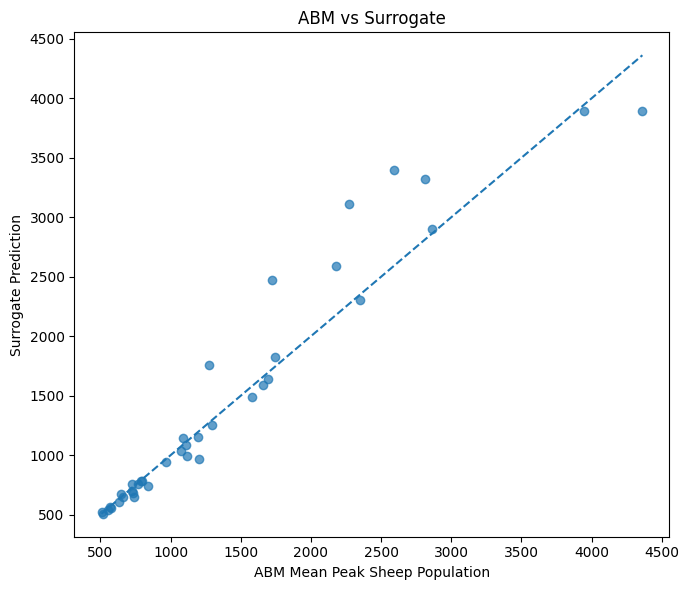

In [19]:
predicted, predicted_std = gp.predict(
    X_test_scaled,
    return_std=True,
)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    predicted,
    alpha=0.7,
)

lower = min(
    y_test.min(),
    predicted.min(),
)

upper = max(
    y_test.max(),
    predicted.max(),
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
)

plt.xlabel("ABM Mean Peak Sheep Population")
plt.ylabel("Surrogate Prediction")
plt.title("ABM vs Surrogate")

plt.tight_layout()
plt.show()

In [20]:
surrogate_performance = pd.DataFrame(
    {
        "Metric": ["R²"],
        "Value": [
            r2_score(
                y_test,
                predicted,
            )
        ],
    }
)

surrogate_performance

,Metric,Value
0,R²,0.909926


### Surrogate Uncertainty

The surrogate does not know the ABM perfectly.

The Gaussian process can also estimate how uncertain it is about each prediction.

Larger predictive uncertainty can indicate regions of the parameter space where additional ABM simulations may be useful.

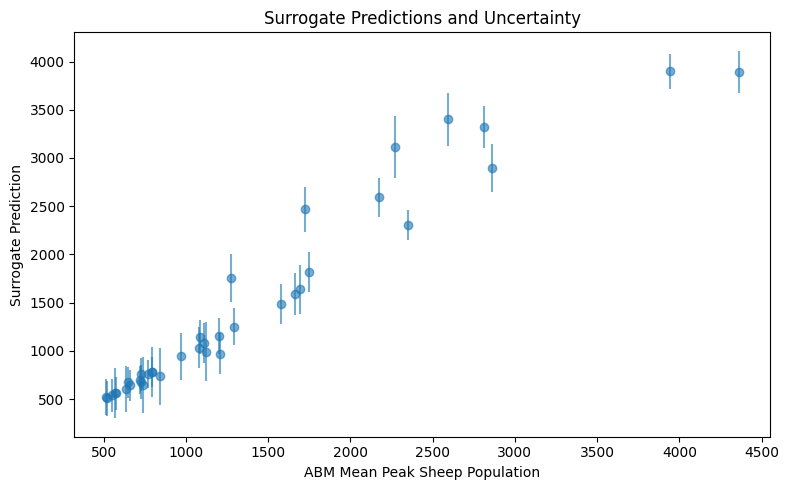

In [21]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    y_test,
    predicted,
    yerr=2 * predicted_std,
    fmt="o",
    alpha=0.6,
)

plt.xlabel("ABM Mean Peak Sheep Population")
plt.ylabel("Surrogate Prediction")
plt.title("Surrogate Predictions and Uncertainty")

plt.tight_layout()
plt.show()

### Is the Surrogate Faster?

The main advantage of a surrogate is that, once trained, it can make predictions without running the original ABM.

To demonstrate this, we evaluate **100 new parameter combinations** using both the ABM and the trained surrogate and compare their execution times.

In [27]:
N_PREDICTIONS = 100

rng = np.random.default_rng(42)

example_parameters = rng.uniform(
    low=bounds[:, 0],
    high=bounds[:, 1],
    size=(N_PREDICTIONS, len(parameter_names)),
)

start = time.perf_counter()

abm_predictions = np.array([
    evaluate_peak(params)
    for params in example_parameters
])

abm_time = (
    time.perf_counter()
    - start
)

start = time.perf_counter()

surrogate_predictions = gp.predict(
    scaler.transform(
        example_parameters
    )
)

surrogate_time = (
    time.perf_counter()
    - start
)

timing = pd.DataFrame(
    {
        "Method": [
            "ABM",
            "Surrogate",
        ],
        "Evaluations": [
            N_PREDICTIONS,
            N_PREDICTIONS,
        ],
        "Time (seconds)": [
            abm_time,
            surrogate_time,
        ],
        "Relative Time": [
            abm_time / surrogate_time,
            1.0,
        ],
    }
)

timing

,Method,Evaluations,Time (seconds),Relative Time
0,ABM,100,13.615040,15420.695783
1,Surrogate,100,0.000883,1.000000


### What Have We Learned About Surrogates?

A surrogate changes the workflow from:

> **Run the ABM every time we need a prediction**

to:

> **Run the ABM to generate training data, then learn a faster approximation**

This can make large parameter searches and calibration more practical.

However, the surrogate introduces **approximation error** and may perform poorly in regions of the parameter space that are not well represented by the training simulations.

## Part B — Simulation-Based Inference

Simulation-Based Inference takes a different approach.

Instead of learning a faster version of the simulator, SBI learns the relationship between:

> **Parameter values ↔ Simulated model outcomes**

We can then provide an observed model outcome and ask:

> **Which parameter values could plausibly have generated this observation?**

Conceptually:

```text
Different parameters → ABM → Different simulated outcomes
                             ↓
                      Learn relationship

Observed outcome → Learned relationship → Plausible parameters
```

### A Small SBI Example

To keep the example manageable, we use only **two parameters**:

- sheep reproduction;
- wolf gain from food.

The remaining parameters are held fixed.

We summarise each simulation using two outputs:

- peak sheep population;
- peak wolf population.

The aim is not to provide a full SBI tutorial, but to demonstrate the basic idea:

> **Simulate many examples, learn the relationship, then use observations to infer plausible parameter values.**

In [28]:
from sbi.inference import NPE
from sbi.utils import BoxUniform

## Define the SBI Simulator

The SBI simulator takes two parameters and returns two model summaries.

Each simulation therefore creates one example of:

> **Parameters → Model outcomes**

In [29]:
def sbi_simulator(theta):
    """Run the ABM for a two-parameter SBI demonstration."""

    sheep_reproduce = float(
        theta[0]
    )

    wolf_gain_from_food = float(
        theta[1]
    )

    result = simulate(
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=0.05,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=5,
        sheep_gain_from_food=12.0,
        seed=None,
    )

    peak_sheep = (
        result["sheep"].max()
    )

    peak_wolves = (
        result["wolves"].max()
    )

    return torch.tensor(
        [
            peak_sheep,
            peak_wolves,
        ],
        dtype=torch.float32,
    )

## Define Prior Parameter Ranges

We tell SBI which parameter values are possible before considering the observation.

In [30]:
def sbi_simulator(theta):
    """Run the ABM for a two-parameter SBI demonstration."""

    sheep_reproduce = float(
        theta[0]
    )

    wolf_gain_from_food = float(
        theta[1]
    )

    result = simulate(
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=0.05,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=5,
        sheep_gain_from_food=12.0,
        seed=None,
    )

    peak_sheep = (
        result["sheep"].max()
    )

    peak_wolves = (
        result["wolves"].max()
    )

    return torch.tensor(
        [
            peak_sheep,
            peak_wolves,
        ],
        dtype=torch.float32,
    )

## Define Prior Parameter Ranges

We tell SBI which parameter values are possible before considering the observation.

In [31]:
prior = BoxUniform(
    low=torch.tensor(
        [
            0.10,
            8.0,
        ],
        dtype=torch.float32,
    ),
    high=torch.tensor(
        [
            0.30,
            16.0,
        ],
        dtype=torch.float32,
    ),
)

## Generate Parameter–Simulation Pairs

We now generate many examples.

For every parameter combination:

1. sample parameter values;
2. run the ABM;
3. record the simulated outcomes.

These examples form the training data used by SBI.

The `sbi` documentation explicitly supports training from parameter–simulation pairs generated outside its helper functions, so this manual construction is appropriate for an existing simulator such as our ABM.

In [33]:
N_SBI_SIMULATIONS = 1000

theta = prior.sample(
    (
        N_SBI_SIMULATIONS,
    )
)

x = torch.stack(
    [
        sbi_simulator(parameters)
        for parameters in theta
    ]
)

theta.shape, x.shape

(torch.Size([1000, 2]), torch.Size([1000, 2]))

theta → parameter values
x     → simulated model outcomes

## What Relationship Are We Learning?

Each point represents one ABM simulation.

For example, we can look at the relationship between sheep reproduction and peak sheep population.

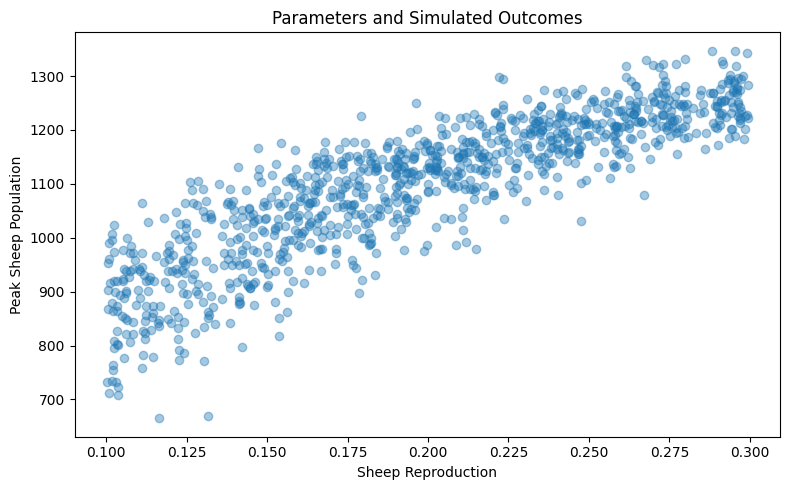

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    theta[:, 0].numpy(),
    x[:, 0].numpy(),
    alpha=0.4,
)

plt.xlabel("Sheep Reproduction")
plt.ylabel("Peak Sheep Population")
plt.title(
    "Parameters and Simulated Outcomes"
)

plt.tight_layout()
plt.show()

The relationship may be noisy because the ABM is stochastic.

SBI does not require every parameter value to map to exactly one model outcome. Instead, it learns from the distribution of simulations generated across the parameter space.

## Train Neural Posterior Estimation

We now train SBI using the simulated parameter–outcome pairs.

The trained model learns which parameter values tend to be associated with different simulated outcomes.  

In [35]:
inference = NPE(
    prior=prior
)

density_estimator = (
    inference
    .append_simulations(
        theta,
        x,
    )
    .train()
)

posterior = (
    inference
    .build_posterior(
        density_estimator
    )
)

 Neural network successfully converged after 172 epochs.

## Create an Observation

For this demonstration, we generate a synthetic observation from known parameter values.

We then pretend that those parameter values are unknown.

In [36]:
true_theta = torch.tensor(
    [
        0.20,
        12.0,
    ],
    dtype=torch.float32,
)

observed_outcome = sbi_simulator(
    true_theta
)

observed_outcome

tensor([1152.,  331.])

## Infer Plausible Parameters

We now provide the observed sheep and wolf population peaks to the trained SBI model.

SBI works backwards from:

> **Observed outcomes → plausible parameter values**

In [37]:
posterior_samples = posterior.sample(
    (2000,),
    x=observed_outcome,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

## Posterior Parameter Distributions

The result is not one best-fitting parameter combination.

Instead, we obtain a distribution of parameter values that are plausible given the observed model outcome.

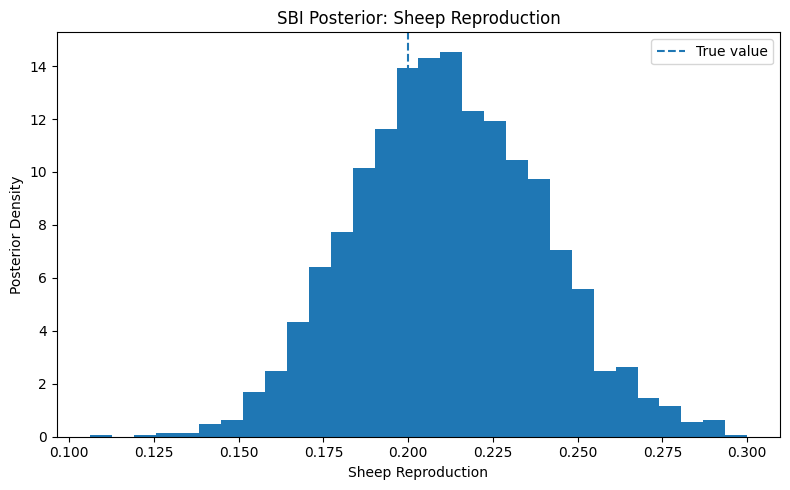

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    posterior_samples[:, 0].numpy(),
    bins=30,
    density=True,
)

plt.axvline(
    true_theta[0].item(),
    linestyle="--",
    label="True value",
)

plt.xlabel("Sheep Reproduction")
plt.ylabel("Posterior Density")
plt.title(
    "SBI Posterior: Sheep Reproduction"
)

plt.legend()
plt.tight_layout()
plt.show()

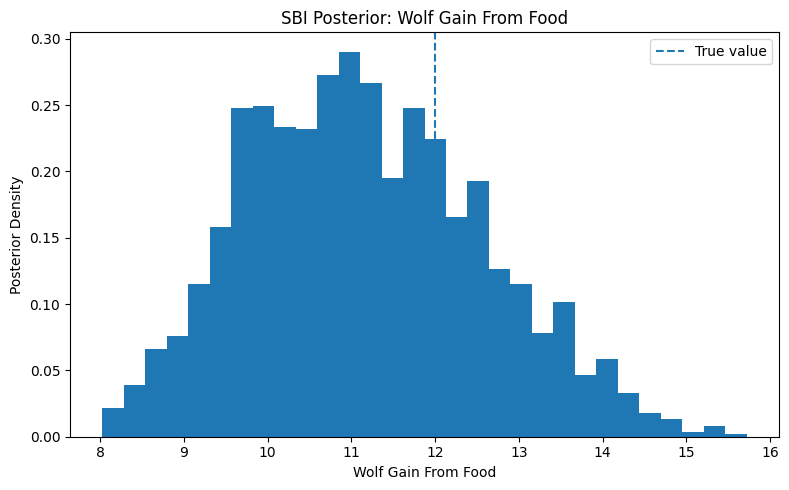

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(
    posterior_samples[:, 1].numpy(),
    bins=30,
    density=True,
)

plt.axvline(
    true_theta[1].item(),
    linestyle="--",
    label="True value",
)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Posterior Density")
plt.title(
    "SBI Posterior: Wolf Gain From Food"
)

plt.legend()
plt.tight_layout()
plt.show()

## Equifinality and SBI

Because SBI produces a distribution rather than one optimum, it can represent situations where several parameter combinations remain plausible.

A bivariate posterior can reveal:

- concentrated regions;
- broad uncertainty;
- parameter correlations; or
- ridges representing parameter trade-offs.

These patterns do not mean SBI has removed equifinality or identifiability problems.

Instead, SBI can help **represent those uncertainties in the inferred parameter distribution**.

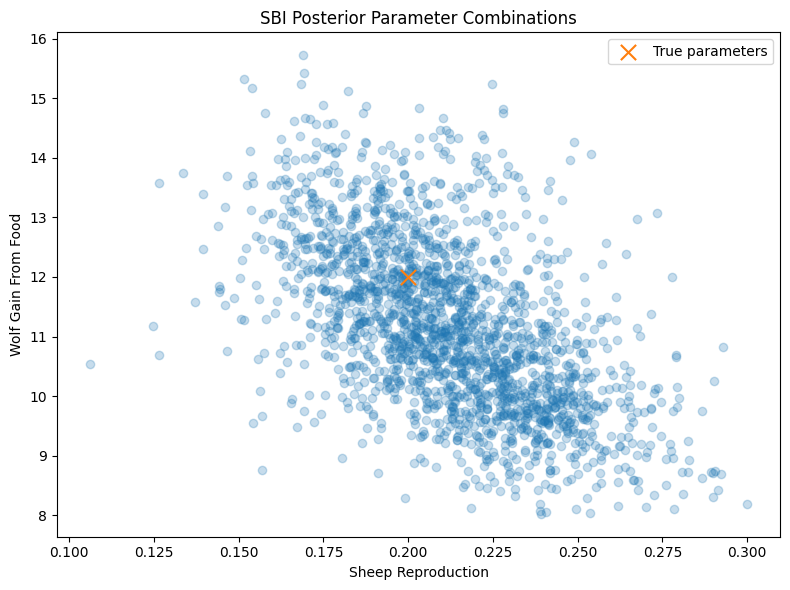

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    posterior_samples[:, 0].numpy(),
    posterior_samples[:, 1].numpy(),
    alpha=0.25,
)

plt.scatter(
    true_theta[0],
    true_theta[1],
    marker="x",
    s=120,
    label="True parameters",
)

plt.xlabel("Sheep Reproduction")
plt.ylabel("Wolf Gain From Food")
plt.title(
    "SBI Posterior Parameter Combinations"
)

plt.legend()
plt.tight_layout()
plt.show()

## Why Can SBI Be Useful?

SBI makes different use of simulations than approaches such as rejection-based ABC.

Instead of using each simulation only to decide whether a parameter combination is sufficiently close to one observation, SBI uses parameter–simulation pairs to **learn a reusable statistical relationship**.

For amortised neural posterior estimation, the trained estimator can be evaluated for different observations without retraining the inference model. This reuse of simulations is one of the important potential advantages of SBI.  

However, SBI is not automatically computationally cheap.

Generating the training simulations and fitting the inference model can itself require substantial computation.

# Surrogates and SBI: What Is the Difference?

Both approaches learn from simulations, but they learn different things.

|  | **Surrogate Modelling** | **Simulation-Based Inference** |
| --- | --- | --- |
| **Learns** | Parameters → model output | Model output → plausible parameters |
| **Main goal** | Approximate an expensive simulator | Infer parameters from simulated examples |
| **Result** | Fast predictions of model behaviour | Distribution of plausible parameter values |
| **Useful when** | The simulator is expensive to evaluate repeatedly | The likelihood is unavailable or difficult to calculate |

A useful simplification is:

> **Surrogates learn to approximate the model. SBI learns how simulated outcomes relate back to parameters.**

## Can We Reuse Existing Simulations?

Yes.

The simulations generated during parameter exploration, sensitivity analysis, or calibration can potentially become useful training data for later methods.

For example:

```text
Parameter-space exploration
        ↓
Existing parameter–simulation pairs
        ↓
   ┌───────────────┐
   │               │
Surrogate          SBI
   │               │
Fast model      Parameter inference
predictions
```

## What Have We Learned?

Complex agent-based models can require large numbers of simulations for exploration and calibration.

Two approaches for making better use of those simulations are:

- **Surrogate modelling:** learn a faster approximation of an expensive model.
- **Simulation-Based Inference:** learn the relationship between parameters and simulated outcomes to infer plausible parameter values.

Neither approach removes stochasticity, equifinality, or identifiability problems.

Instead, they provide additional tools for working with complex simulation models more efficiently.

> **Instead of discarding simulations after each analysis, can we learn from them and reuse what we have learned?**